In [1]:
import sympy as sym
from sympy.vector import CoordSys3D, Del
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

## Building an Effective Field Theory: 
### Coulombic atom w/ short-range potential

---
This notebook is an exercise following Section 2 of G. P. Lepage's [article](https://arxiv.org/pdf/nucl-th/9706029) illustrating the key ideas of effective field theories.

The goal is to develop an approximate theory that fits some arbitrary physical system described by a collection of low-energy "synthetic data".
The example system used by Lepage is a Hydrogenic atom featuring a Coulombic potential $\frac{\alpha}{r}$ and an additional short-range potential $V_s(r)$


$$H = -\frac{\hbar^2}{2m}\nabla^2 + V(r) \\[10pt]
V(r) = -\frac{\alpha}{r} + V_s(r)$$

Lepage does not specify the form of $V_s(\mathbf{r})$ that he used to generate his data, to show that you can produce an effective theory using only the data.
In our example, we will use an inverse-quartic formula with constant $\beta$

$$V_s(\mathbf{r}) = \frac{\beta}{r^4}$$

For simplicity lwe will work in atomic units ($m=\hbar=\alpha=\beta=1$). By solving the time-independent Schrodinger's equation we may obtain the radial wavefunctions of the energy eigenstates of this system

$$ H\psi_n(\mathbf{r}) = \left ( - \frac{\nabla^2}{2} + V(\mathbf{r})  \right ) \psi_n(\mathbf{r}) = E_n \psi_n(\mathbf{r}) $$

Analytical derivation involves expanding the Laplacian into spherical coordinates and other complicated steps that I don't want to do, so let's instead create a numerical eigensolver through the **SymPy** library.

In [66]:
#Define 3D coordinate system
R = CoordSys3D('R')

#Define position vector
x, y, z = sym.symbols('x, y, z', real=True)
r = x*R.i + y*R.j + z*R.k
r.magnitude()

sqrt(x**2 + y**2 + z**2)

In [67]:
#Define eigenfunction
psi = sym.symbols('psi', cls=sym.Function, complex=True)
psi = psi(r)

#Define eigenenergy
E = sym.symbols('E', real=True)

#Define scalar potential field
V = sym.symbols('V', cls=sym.Function,  real=True)
V = V(r)
Vs = r.magnitude()**(-4)
V = -1*r.magnitude()**(-1) + Vs

In [68]:
V

(x**2 + y**2 + z**2)**(-2) - 1/sqrt(x**2 + y**2 + z**2)

In [69]:

#  Note - Laplacian(f) <=> div(grad(f))
# div is delop.dot() and grad is delop()
delop = Del()
def Lap(state):
    return delop.dot(delop(state))

# Subtract RHS from LHS to get expression
# for Schrodingers equation which equals zero
schdeq = -1*sym.Rational(1,2)*Lap(psi) + (V-E)*psi

In [70]:
#Try to solve for eigenstate and eigenenergy
sols = sym.pdsolve(schdeq)




NotImplementedError: Right now only partial differential equations of two variables are supported

---
The PDE solver in SymPy does not support equations with more than two variables. So much for the easy way...

The next thing to try is representing the equation as a separable PDE where
$$ \psi = R(r)Y(\theta, \phi) $$

The Laplacian in spherical coordinates is

$$ \nabla^2 \psi = \frac{1}{r^2}\frac{\partial}{\partial r} \left ( r^2 \frac{\partial \psi}{\partial r} \right ) + \frac{1}{r^2\sin\theta}\frac{\partial}{\partial \theta} \left ( \sin\theta \frac{\partial \psi}{\partial \theta} \right ) + \frac{1}{r^2\sin^2\theta}\frac{\partial^2 \psi}{\partial \phi^2} $$

and after some rearranging, the Schrodinger's equation becomes

$$ \frac{RY}{r^2} \left [ \frac{1}{R}\frac{\partial}{\partial r} \left ( r^2 \frac{\partial}{\partial r} \right ) R - 2r^2 \left \{ V(r)-E \right \} \right ] = -\frac{RY}{r^2} \left [ \frac{1}{Y\sin\theta}\frac{\partial}{\partial \theta}\left ( \sin\theta \frac{\partial}{\partial \theta} \right ) Y + \frac{1}{Y\sin^2\theta}\frac{\partial^2}{\partial \phi^2} Y \right ] $$

Both sides of the equation are independent of each other (i.e. shifting $r$ doesn't change $Y$) so are only valid if they equate to some separation constant $K$. Our interest lies only on the left hand side of the equation, which contains the **radial equation**. We make the substitution $x(r) = rR(r)$ to obtain

$$ \frac{r}{x}\left ( r \frac{d^2 x}{dr^2} \right ) - 2r^2 \left [-\frac{1}{r}+\frac{1}{r^4}-E\right ] - K = 0 \\[10pt]
 \Rightarrow \qquad  \frac{d^2 x}{dr^2}  - \left [\frac{2}{r}+\frac{2}{r^4}-E - \frac{K}{r^2}\right ]x = 0
 $$


In [ ]:
K = 10
E = sym.symbols('E', real=True, positive=False)
r = sym.symbols('r', real=True)
psi = sym.symbols('psi', cls=sym.Function, complex=True)
psi = psi(r)

In [ ]:
radeq = sym.diff(psi, r, 2) - (2/r - E - K*r**(-2))*psi
sym.dsolve(radeq)

ValueError: Expected Expr or iterable but got None

---
The `dsolve` method did not like that expression either, so we will instead  solve numerically using SciPy.

In [ ]:
radeq_low_order_terms = (2/r - E - K*r**(-2))*psi

# The solve_bvp method only takes first order ODEs, so need to define a system of ODEs
def bvp_func(r, psi, E):
    ddivpsi = (2/r - E[0] - r**(-2))*psi[0]
    return np.vstack((psi[1], ddivpsi))

# Method needs function to return boundary condition residuals
def bc(psi_zero, psi_inf, E):
    return np.array([psi_zero[0], psi_inf[0], psi_zero[1] - 1.0])

# Initialise radius value range and limits
r_min = 0.001
r_max = 100
r = np.linspace(r_min, r_max, 1000)

# Wavefunction guess (should be complex-valued)
psi_guess = np.zeros((2, r.size), dtype=complex)
psi_guess[0,:] = r * np.exp(-r) + 0j

# Eigenenergy guess
E_guess = np.array([-1.0])

# Numerical solver
sol = solve_bvp(bvp_func, bc,
                r, psi_guess, p=E_guess)




/home/zanevc/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/zanevc/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


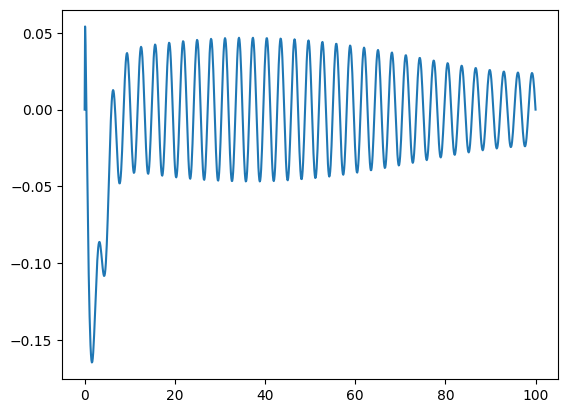

In [ ]:
plt.plot(r, sol.sol(r)[0])
plt.show()

In [ ]:
sol.p[0]

np.complex128(4.098253682789708+0j)

### Numerical solver for Hydrogenic atom radial equation

$$\left [ -\frac{\hbar^2}{2m}\nabla^2 -\frac{\alpha}{r}\right ]\psi = E\psi$$

$$\frac{1}{R}\frac{d}{dr}\left ( r^2 \frac{dR}{dr} \right ) -\frac{2mr^2}{\hbar^2} \left ( -\frac{\alpha}{r} - E \right ) = 0$$

$$ \frac{\hbar^2}{2m}\frac{d^2R}{dr^2}+\frac{\hbar^2}{mr}\frac{dR}{dr} + ER + \frac{\alpha}{r}R = \frac{\hbar^2}{2mr^2}KR $$

We will examine the s-orbital wavefunction, which means $l=0$ and $K=l(l+1)=0$.

In [ ]:
# ATOMIC UNITS
#Mass of electron
#m = 9.109e-31
m = 1.0
#Plancks constant
#hbar = 6.63e-34
hbar = 1.0
#Electron charge
#q = -1.6e-19
q = 1.0
#Free permitivity
alpha = q**2

$$ \frac{d}{dr}\left ( r^2 \frac{d}{dr}R \right ) = r^2\frac{d^2 R}{dr^2} + 2r\frac{dR}{dr} \\[10pt]
R = \frac{u}{r} \\[10pt]
\frac{d}{dr}\left ( \frac{u}{r} \right ) = \frac{ru' - u}{r^2} = \frac{u'}{r} - \frac{u}{r^2} \\[10pt]
\frac{d^2}{dr}\left ( \frac{u}{r} \right ) = \frac{ru''-u'}{r^2} - \frac{r^2u'-2ru}{r^4} \\[10pt]
= \frac{u''}{r} - \frac{2u'}{r^2} + \frac{2u}{r^3} \\[10pt]
r^2\left ( \frac{u''}{r} - \frac{2u'}{r^2} + \frac{2u}{r^3}  \right ) + 2r \left ( \frac{u'}{r} - \frac{u}{r^2} \right ) = r \frac{d^2 u}{dr^2} $$

$$ r\left [ \frac{d^2u}{dr^2} + \frac{2m}{\hbar^2} \left ( \frac{e^2}{r} + E \right )u \right ] = 0 $$

In [75]:

# The solve_bvp method only takes first order ODEs, so need to define a system of ODEs
def bvp_func(r, psi, E):
    ddivpsi =  -2*(E[0] + 1/r)*psi[0]
    return np.vstack((psi[1], ddivpsi))

# Method needs function to return boundary condition residuals
def bc(psi_zero, psi_inf, E):
    return np.array([psi_zero[0], psi_inf[0], psi_zero[1] - 1.0])

# Initialise radius value range and limits
r_min = 0.01
r_max = 10
r = np.linspace(r_min, r_max, 3000)

# Wavefunction guess (should be complex-valued)
psi_guess = np.zeros((2, r.size))
psi_guess[0,:] = r *  np.exp(-r)
psi_guess[1, :] = np.exp(r) - r * np.exp(-r)

# Eigenenergy guess
E_guess = np.array([-0.5])

# Numerical solver
sol = solve_bvp(bvp_func, bc,
                r, psi_guess, p=E_guess, tol=1e-6)

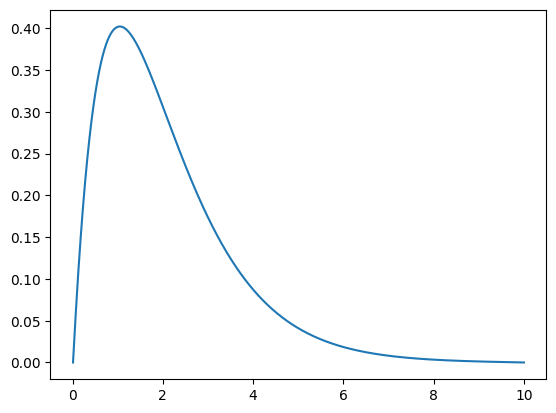

In [ ]:
plt.plot(r, sol.sol(r)[0])
plt.show()

In [ ]:
print("Solved energy:", sol.p[0])

Solved energy: -0.4821057595546173


### Now plug in our quartic Coulombic potential into the radial equation

In [86]:
def bvp_func2(r, psi, E):
    ddivpsi =  -2*(E[0] + 1/r - r**(-4))*psi[0]
    return np.vstack((psi[1], ddivpsi))

sol2 = solve_bvp(bvp_func2, bc,
                r, psi_guess, p=E_guess, tol=1e-6)

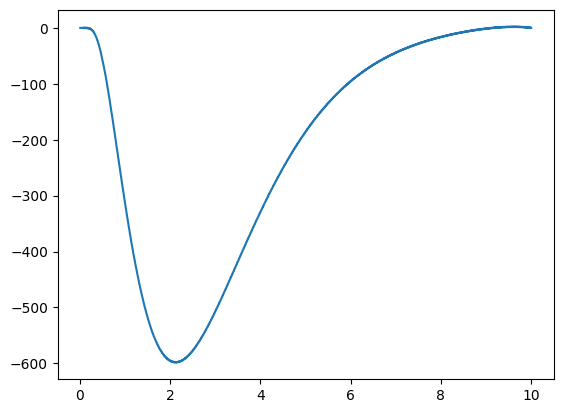

In [87]:
plt.plot(r, sol2.sol(r)[0])
plt.show()

In [88]:
print("Solved energy:", sol.p[0])

Solved energy: -0.4821057595546173
